<h1>imports</h1>

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

<h1>Imported Data from yfinance</h1>

In [2]:


sp500 = yf.download("^GSPC", period="5d")
print(sp500.head())
print(sp500.dtypes)






[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2026-03-06  6740.020020  6773.419922  6711.560059  6769.029785  5793120000
2026-03-09  6795.990234  6810.439941  6636.040039  6699.799805  6709410000
2026-03-10  6781.479980  6845.080078  6759.740234  6796.560059  5944950000
2026-03-11  6775.799805  6811.149902  6745.589844  6790.089844  5511090000
2026-03-12  6672.620117  6740.879883  6670.399902  6740.879883  3496195000
Price   Ticker
Close   ^GSPC     float64
High    ^GSPC     float64
Low     ^GSPC     float64
Open    ^GSPC     float64
Volume  ^GSPC       int64
dtype: object


This is where we cleaned the data

In [3]:
def clean_data():
    for col in sp500.columns:
        sp500[col] = pd.to_numeric(sp500[col], errors='coerce')
        
    sp500.index = pd.to_datetime(sp500.index)
    sp500.sort_index(inplace=True)
    sp500.dropna(inplace=True)
        
    return sp500
    
clean_sp500 = clean_data()
print(clean_sp500.head())

print("="*60)
print("validating clean data")
print("="*60)
print(f"Missing values: {clean_sp500.isnull().sum().sum()}")
print(f"Data types:\n{clean_sp500.dtypes}")
print(f"Date range: {clean_sp500.index[0].date()} to {sp500.index[-1].date()}")
print(f"Number of trading days: {len(clean_sp500)}")

# Basic validation checks
print(f"\nValidation:")
print(f"High >= Low: {(clean_sp500['High'] >= clean_sp500['Low']).all()}")
print(f"High >= Open: {(clean_sp500['High'] >= clean_sp500['Open']).all()}")
print(f"High >= Close: {(clean_sp500['High'] >= clean_sp500['Close']).all()}")
print(f"Low <= Open: {(clean_sp500['Low'] <= clean_sp500['Open']).all()}")
print(f"Low <= Close: {(clean_sp500['Low'] <= clean_sp500['Close']).all()}")

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2026-03-06  6740.020020  6773.419922  6711.560059  6769.029785  5793120000
2026-03-09  6795.990234  6810.439941  6636.040039  6699.799805  6709410000
2026-03-10  6781.479980  6845.080078  6759.740234  6796.560059  5944950000
2026-03-11  6775.799805  6811.149902  6745.589844  6790.089844  5511090000
2026-03-12  6672.620117  6740.879883  6670.399902  6740.879883  3496195000
validating clean data
Missing values: 0
Data types:
Price   Ticker
Close   ^GSPC     float64
High    ^GSPC     float64
Low     ^GSPC     float64
Open    ^GSPC     float64
Volume  ^GSPC       int64
dtype: object
Date range: 2026-03-06 to 2026-03-12
Number of trading days: 5

Validation:
High >= Low: Ticker
^GSPC    True
dtype: bool
High >= Open: Ticker
^GSPC    True
dtype: bool
High >= Close: Ticke

<h1>EDA</h1>

In [3]:
print("="*60)
print("NUMERICAL VARIABLE SUMMARY")
print("="*60)
print(clean_sp500.describe().round(2))

NUMERICAL VARIABLE SUMMARY
Price     Close     High      Low     Open        Volume
Ticker    ^GSPC    ^GSPC    ^GSPC    ^GSPC         ^GSPC
count      5.00     5.00     5.00     5.00  5.000000e+00
mean    6886.42  6904.76  6822.78  6868.21  5.494333e+09
std       47.49    46.80    76.28    60.70  1.208106e+09
min     6816.63  6840.05  6710.42  6800.26  3.509315e+09
25%     6878.88  6882.96  6796.85  6824.36  5.328060e+09
50%     6881.62  6901.01  6831.74  6856.54  5.889550e+09
75%     6908.86  6947.25  6859.73  6915.15  6.079080e+09
max     6946.13  6952.51  6915.15  6944.74  6.665660e+09


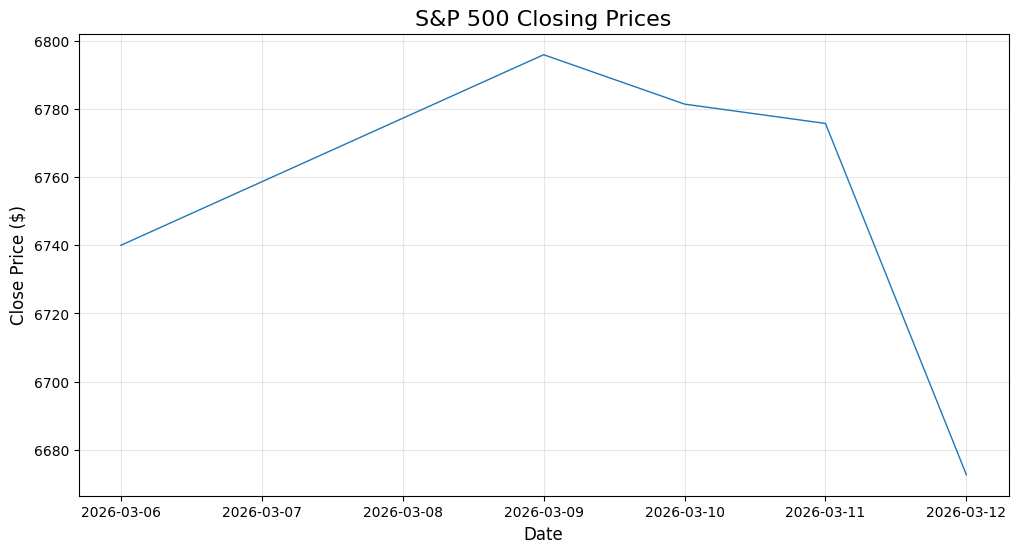

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(clean_sp500.index, clean_sp500['Close'], linewidth=1)
plt.title('S&P 500 Closing Prices', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

<h1>feature engineering</h1>